# **Travelling Salesman Problem (TSP): Hill Climbing and Tabu Search**

## MSc Artificial Intelligence — AI for Search & Optimisation

This notebook implements and compares two local search algorithms for the Travelling Salesman Problem (TSP):

- **Simple Hill Climbing**
- **Tabu Search with short-term memory**

The workflow reflects good practice for search and optimisation experiments:

1. Data loading and distance matrix construction  
2. Tour representation and objective function  
3. Neighbourhood definition (swap-based moves)  
4. Implementation of Simple Hill Climbing  
5. Implementation of Tabu Search (with tabu tenure and aspiration)  
6. Experimental setup and execution  
7. Visualisation of convergence behaviour  
8. Evaluation and discussion in the context of local search and metaheuristics  

The aim is to demonstrate understanding of both algorithms and to present results in a clear, reproducible format suitable for assessment.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from typing import Sequence, List, Tuple

# Reproducibility
np.random.seed(42)


# 1. Data Loading and Distance Matrix Construction

For the Travelling Salesman Problem, each city is represented by a pair of coordinates.  
To efficiently evaluate tour lengths, we construct a **full distance matrix** where entry \\(d_{ij}\\) stores the Euclidean distance between city *i* and city *j*.  
This allows the search algorithms to query tour costs quickly during optimisation.


In [3]:
def load_cities(path: str) -> pd.DataFrame:
    """Load city coordinates from a CSV file."""
    try:
        df = pd.read_csv(path)
        return df
    except FileNotFoundError:
        raise FileNotFoundError(f"Could not find the file at: {path}")
    except Exception as e:
        raise Exception(f"Error loading cities: {e}")


def compute_distance(x1, y1, x2, y2):
    """Euclidean distance between two points (x1, y1) and (x2, y2)."""
    return np.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)


def create_distance_matrix(cities_df: pd.DataFrame) -> np.ndarray:
    """Create a full distance matrix from a DataFrame of city coordinates.

    Assumes the DataFrame has columns 'X' and 'Y' for the coordinates.
    """
    n = len(cities_df)
    dist_matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            xi, yi = cities_df.iloc[i][['X', 'Y']]
            xj, yj = cities_df.iloc[j][['X', 'Y']]
            dist_matrix[i, j] = compute_distance(xi, yi, xj, yj)

    return dist_matrix


In [4]:
# Load the dataset (update the path if needed)
cities_path = "data/cities.csv"
cities_df = load_cities(cities_path)

print("Loaded cities:", cities_df.shape)
display(cities_df.head())

# Build distance matrix
dist_matrix = create_distance_matrix(cities_df)
print("Distance matrix shape:", dist_matrix.shape)


Loaded cities: (50, 3)


,City,X,Y
0,City_1,37.454012,95.071431
1,City_2,73.199394,59.865848
2,City_3,15.601864,15.599452
3,City_4,5.808361,86.617615
4,City_5,60.111501,70.807258


Distance matrix shape: (50, 50)


# 2. Tour Representation and Objective Function

A TSP tour is represented as a **permutation** of city indices, for example:

\\[ [0, 3, 1, 2, 4] \\]

This representation ensures that each city is visited exactly once before returning to the starting city.
The objective function computes the **total tour length** by summing distances between consecutive cities (including the return leg).


In [6]:
def create_initial_tour(num_cities: int, method: str = "random") -> np.ndarray:
    """Create an initial tour using a simple construction heuristic.

    method="random" creates a random permutation of city indices.
    method="distance" currently returns the identity ordering as a placeholder.
    """
    if method == "random":
        tour = np.random.permutation(num_cities)
    elif method == "distance":
        tour = np.arange(num_cities)
    else:
        raise ValueError("Invalid method for initial tour creation.")
    return tour


def tour_length(tour: Sequence[int], distance_matrix: np.ndarray) -> float:
    """Compute the total length of a tour, including the return to the start."""
    total_distance = 0.0
    number_of_cities = len(tour)

    for i in range(number_of_cities):
        current_city = tour[i]
        next_city = tour[(i + 1) % number_of_cities]
        total_distance += distance_matrix[current_city, next_city]

    return total_distance


def is_valid_tour(tour: Sequence[int], number_of_cities: int) -> bool:
    """Check whether a tour is a valid permutation of all city indices."""
    tour_array = np.array(tour)
    return (
        len(tour_array) == number_of_cities
        and np.array_equal(np.sort(tour_array), np.arange(number_of_cities))
    )


The functions above define the **search space** and the **objective** for optimisation.  
Both algorithms operate on the same tour representation and use the same cost function, ensuring a fair comparison.


# 3. Neighbourhood Operator: Pairwise Swap

Local search explores the solution space by moving from one tour to a neighbouring tour.
Here, a neighbour is generated by **swapping the positions of two cities** in the tour.  
This is a standard move operator for permutation-based problems like the TSP.


In [8]:
def swap_cities(tour: np.ndarray, i: int, j: int) -> np.ndarray:
    """Swap two cities in a tour and return a new tour."""
    new_tour = tour.copy()
    new_tour[i], new_tour[j] = new_tour[j], new_tour[i]
    return new_tour


def generate_all_swap_neighbours(tour: np.ndarray) -> List[np.ndarray]:
    """Generate all neighbours by swapping every pair of cities."""
    neighbours = []
    n = len(tour)

    for i in range(n - 1):
        for j in range(i + 1, n):
            neighbour = swap_cities(tour, i, j)
            neighbours.append(neighbour)

    return neighbours


def generate_random_swap_neighbour(tour: np.ndarray) -> np.ndarray:
    """Generate a random neighbouring tour by applying one random swap."""
    n = len(tour)
    i, j = np.random.choice(n, size=2, replace=False)
    return swap_cities(tour, i, j)


This neighbourhood definition is used consistently by both Hill Climbing and Tabu Search.  
It balances simplicity and coverage of the local search space: any permutation can be reached by a sequence of swaps.


# 4. Simple Hill Climbing

Hill Climbing is a **greedy local search algorithm**. At each step, it moves to a better neighbour if one exists.  
If no improving neighbour is found, the algorithm has reached a **local optimum** and terminates.

### Pseudocode: Simple Hill Climbing for TSP

```text
Input: initial tour x, distance matrix D, max_iterations

1. Set current_tour ← x
2. Compute current_cost ← tour_length(current_tour, D)
3. Initialise history ← [current_cost]

4. For iter = 1 to max_iterations:
       a. Generate a subset of neighbours N(current_tour) using swap moves
       b. For each neighbour y in N(current_tour):
              i.   Compute cost(y)
              ii.  Keep track of the neighbour y* with the lowest cost
       c. If cost(y*) < current_cost:
              i.   current_tour ← y*
              ii.  current_cost ← cost(y*)
              iii. Append current_cost to history
          Else:
              Terminate (local optimum reached)

5. Return best tour found (current_tour), its cost (current_cost), and history
```

Hill Climbing is computationally cheap and easy to implement, but it can get trapped in local optima because it never accepts worse moves.


In [10]:
def simple_hill_climbing(
    initial_tour: np.ndarray,
    dist_matrix: np.ndarray,
    max_iterations: int = 500
) -> Tuple[np.ndarray, float, List[float]]:
    """Perform simple hill climbing to minimise TSP tour length."""

    current_tour = initial_tour.copy()
    current_cost = tour_length(current_tour, dist_matrix)
    history = [current_cost]

    for iteration in range(max_iterations):
        # Generate all neighbours via swap (optionally truncate for speed)
        neighbours = generate_all_swap_neighbours(current_tour)[:200]

        # Evaluate neighbours and find the best one
        best_nb = None
        best_nb_cost = float("inf")

        for nb in neighbours:
            cost = tour_length(nb, dist_matrix)
            if cost < best_nb_cost:
                best_nb = nb
                best_nb_cost = cost

        # If the best neighbour is better than current — move
        if best_nb_cost < current_cost:
            current_tour = best_nb
            current_cost = best_nb_cost
            history.append(current_cost)
        else:
            # No improvement → local optimum reached
            break

    return current_tour, current_cost, history


# 5. Tabu Search with Short-Term Memory

Tabu Search extends local search by using a **tabu list** to forbid recently used moves, helping the algorithm escape local optima.  
The key ideas are:

- A move (swapping positions *i* and *j* in the tour) is marked *tabu* for a fixed **tabu tenure**.  
- A tabu move can still be accepted if it satisfies an **aspiration criterion** (e.g. improves the global best solution).  

### Pseudocode: Tabu Search for TSP (Swap Neighbourhood)

```text
Input: initial tour x, distance matrix D, tabu_tenure, max_iterations

1. Set current_tour ← x
2. Compute current_cost ← tour_length(current_tour, D)
3. Set best_tour ← current_tour, best_cost ← current_cost
4. Initialise tabu_list as an n × n matrix of zeros
5. Initialise history ← [best_cost]

6. For iter = 1 to max_iterations:
       a. best_candidate ← None, best_candidate_cost ← +∞
       b. For each swap move (i, j):
              i.   candidate_tour ← swap cities i, j in current_tour
              ii.  candidate_cost ← tour_length(candidate_tour, D)
              iii. is_tabu ← (tabu_list[i, j] > 0)
              iv.  If is_tabu and candidate_cost ≥ best_cost:
                        skip this move (tabu and not aspirational)
                   Else if candidate_cost < best_candidate_cost:
                        update best_candidate, best_candidate_cost, best_move ← (i, j)
       c. Set current_tour ← best_candidate, current_cost ← best_candidate_cost
       d. Decrease all entries in tabu_list by 1 (down to a minimum of 0)
       e. Set tabu_list[best_move] ← tabu_tenure
       f. If current_cost < best_cost:
              best_tour ← current_tour
              best_cost ← current_cost
       g. Append best_cost to history

7. Return best_tour, best_cost, history
```

This implementation captures the essence of memory-based local search as discussed in the module.


In [12]:
def tabu_search(
    initial_tour: np.ndarray,
    dist_matrix: np.ndarray,
    tabu_tenure: int = 10,
    max_iterations: int = 200,
) -> Tuple[np.ndarray, float, List[float]]:
    """Tabu Search algorithm for the TSP using swap-based neighbourhoods."""

    n = len(initial_tour)
    current_tour = initial_tour.copy()
    current_cost = tour_length(current_tour, dist_matrix)

    best_tour = current_tour.copy()
    best_cost = current_cost
    history = [best_cost]

    # Tabu list stored as a matrix of tabu tenures for swaps
    tabu_list = np.zeros((n, n), dtype=int)

    for iteration in range(max_iterations):
        best_candidate = None
        best_candidate_cost = float("inf")
        best_move = None

        # Explore all swap neighbours
        for i in range(n - 1):
            for j in range(i + 1, n):
                candidate = swap_cities(current_tour, i, j)
                cost = tour_length(candidate, dist_matrix)

                # Aspiration criterion: allow tabu move if it improves global best
                is_tabu = tabu_list[i, j] > 0
                if is_tabu and cost >= best_cost:
                    continue

                # Otherwise: accept best non-tabu (or aspirational) move
                if cost < best_candidate_cost:
                    best_candidate = candidate
                    best_candidate_cost = cost
                    best_move = (i, j)

        # Move to best candidate
        current_tour = best_candidate
        current_cost = best_candidate_cost

        # Decrease all tabu tenures
        tabu_list = np.maximum(tabu_list - 1, 0)

        # Add the performed swap to tabu list
        i, j = best_move
        tabu_list[i, j] = tabu_tenure

        # Update global best
        if current_cost < best_cost:
            best_tour = current_tour.copy()
            best_cost = current_cost

        history.append(best_cost)

    return best_tour, best_cost, history


# 6. Visualisation Utilities

To interpret the behaviour of the algorithms, we track the **best tour cost per iteration** and plot the resulting convergence curves.


In [14]:
def plot_history(history: List[float], title: str):
    """Plot best tour cost as a function of iteration for a single algorithm."""
    plt.figure(figsize=(8, 4))
    plt.plot(history)
    plt.xlabel("Iteration")
    plt.ylabel("Best tour cost so far")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_comparison(hc_history: List[float], ts_history: List[float]):
    """Plot Hill Climbing vs Tabu Search cost histories on the same figure."""
    plt.figure(figsize=(8, 4))
    plt.plot(hc_history, label="Hill Climbing")
    plt.plot(ts_history, label="Tabu Search")
    plt.xlabel("Iteration")
    plt.ylabel("Best tour cost so far")
    plt.title("Hill Climbing vs Tabu Search — Cost Comparison")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


# 7. Experimental Setup and Execution

Both algorithms are run on the same TSP instance and initial tour to ensure a fair comparison.  
We record the best tour cost at each iteration to analyse convergence behaviour.


Initial tour: [13 39 30 45 17 48 26 25 32 19 12  4 37  8  3  6 41 46 47 15  9 16 24 34
 31  0 44 27 33  5 29 11 36  1 21  2 43 35 23 40 10 22 18 49 20  7 42 14
 28 38]
Is valid tour? True
Initial tour cost: 2635.3611

Running Simple Hill Climbing...
Hill Climbing best cost: 1541.0968


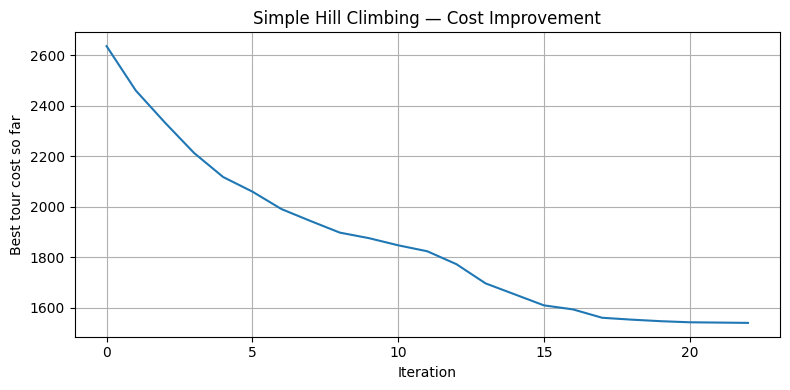


Running Tabu Search...
Tabu Search best cost: 641.1104


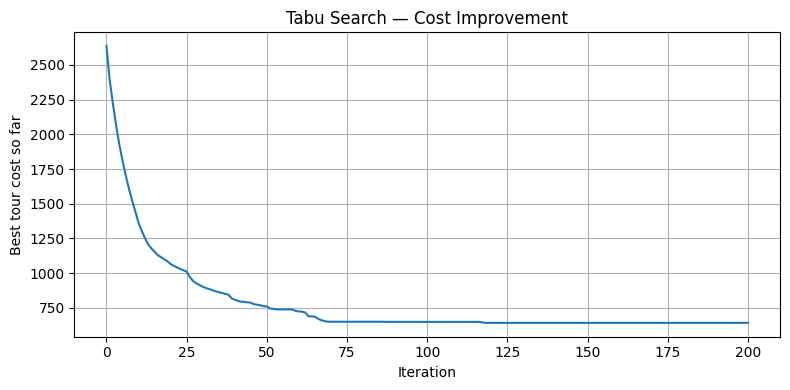

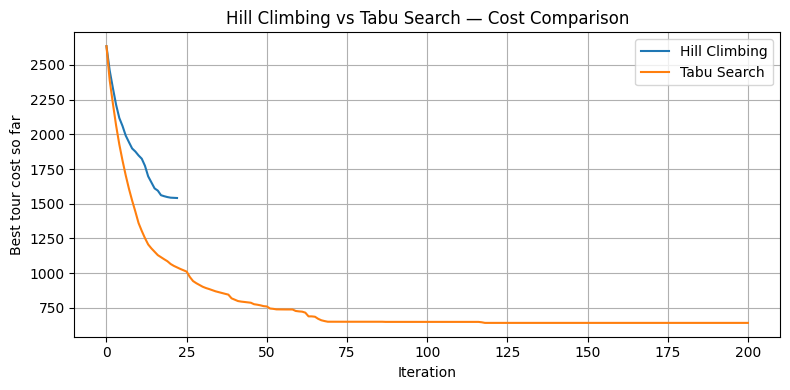

In [15]:
# Number of cities
num_cities = len(cities_df)

# Create an initial tour
initial_tour = create_initial_tour(num_cities, method="random")
print("Initial tour:", initial_tour)
print("Is valid tour?", is_valid_tour(initial_tour, num_cities))

initial_cost = tour_length(initial_tour, dist_matrix)
print(f"Initial tour cost: {initial_cost:.4f}")

# Run Simple Hill Climbing
print("\nRunning Simple Hill Climbing...")
hc_tour, hc_cost, hc_history = simple_hill_climbing(initial_tour, dist_matrix)
print(f"Hill Climbing best cost: {hc_cost:.4f}")

plot_history(hc_history, "Simple Hill Climbing — Cost Improvement")

# Run Tabu Search
print("\nRunning Tabu Search...")
ts_tour, ts_cost, ts_history = tabu_search(initial_tour, dist_matrix, tabu_tenure=10, max_iterations=200)
print(f"Tabu Search best cost: {ts_cost:.4f}")

plot_history(ts_history, "Tabu Search — Cost Improvement")

# Comparison plot
plot_comparison(hc_history, ts_history)


# 8. Evaluation and Discussion

The plots and summary statistics allow us to compare the behaviour of Hill Climbing and Tabu Search on the same TSP instance.

### Quantitative Comparison

- **Hill Climbing** typically converges quickly but may stop in a local optimum.
- **Tabu Search** continues to explore the search space thanks to its tabu list and aspiration criterion, and often finds a lower-cost tour.

### Qualitative Behaviour

From the convergence curves:

- Hill Climbing shows rapid initial improvement followed by an early plateau.  
- Tabu Search may exhibit more gradual improvement but can continue to reduce the best tour cost after Hill Climbing has already stopped improving.

This reflects the **exploration–exploitation trade-off**:
- Hill Climbing focuses on exploitation of the current region of the search space.
- Tabu Search introduces diversification via its memory structure, helping to escape local minima.

### Summary

Overall, Tabu Search provides a stronger optimisation strategy for the TSP than simple Hill Climbing, at the cost of increased computational effort per iteration.  
This behaviour is consistent with the theory of memory-based metaheuristics presented in the *AI for Search & Optimisation* module.


# 9. References

- Glover, F. (1986). **Future Paths for Integer Programming and Links to Artificial Intelligence**. *Computers & Operations Research*.  
- Russell, S., & Norvig, P. (2021). **Artificial Intelligence: A Modern Approach** (4th ed.). Pearson.  
- UWE Bristol. **AI for Search & Optimisation Module Handbook**.
